In [1]:
import os
import pandas as pd

In [12]:
folder_path = r'C:\Users\USER\Desktop\data\cleaned'
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# 딕셔너리로 바로 읽기
df_dict = {file: pd.read_csv(os.path.join(folder_path, file)) for file in csv_files}

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14528\869489609.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dict = {file: pd.read_csv(os.path.join(folder_path, file)) for file in csv_files}


In [14]:
# 각 파일의 컬럼명을 출력
for file_name, df in zip(csv_files, df_list):  # parquet 파일이면 csv_files → parquet_files로 바꾸기
    print(f"📄 {file_name} 컬럼 목록:")
    print(df.columns.tolist())
    print("-" * 50)

📄 distribution_centers_EDA.csv 컬럼 목록:
['id', 'name', 'latitude', 'longitude']
--------------------------------------------------
📄 events_EDA.csv 컬럼 목록:
['id', 'user_id', 'sequence_number', 'session_id', 'created_at', 'ip_address', 'city', 'state', 'postal_code', 'browser', 'traffic_source', 'uri', 'event_type']
--------------------------------------------------
📄 inventory_items_EDA.csv 컬럼 목록:
['id', 'product_id', 'created_at', 'sold_at', 'cost', 'product_category', 'product_name', 'product_brand', 'product_retail_price', 'product_department', 'product_sku', 'product_distribution_center_id', 'created_year', 'created_month', 'created_day', 'created_weekday']
--------------------------------------------------
📄 orders_EDA.csv 컬럼 목록:
['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at', 'shipped_at', 'delivered_at', 'num_of_item', 'is_returned', 'shipping_days', 'lead_time']
--------------------------------------------------
📄 order_items_EDA.csv 컬럼 목록:
['id', 'order_i

### 가설1. 배송 리드타임이 길수록 반품 확률이 높아진다.

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 윈도우 기준: 한글 폰트 설정 (맑은 고딕)
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14528\102260935.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return_rate = orders.groupby('lead_time_group')['is_returned'].mean().reset_index()


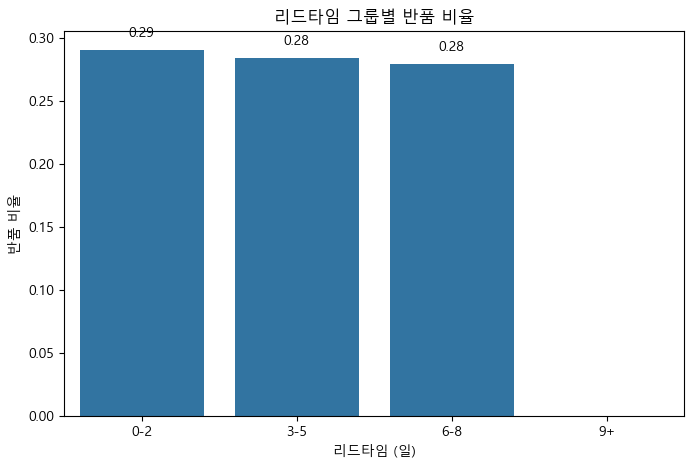

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

orders = df_dict['orders_EDA.csv']

# 리드타임 그룹핑 (예: 0~2, 3~5, 6~8, 9+)
orders['lead_time_group'] = pd.cut(orders['lead_time'], bins=[-1, 2, 5, 8, 100], labels=['0-2', '3-5', '6-8', '9+'])

# 그룹별 반품률 계산
return_rate = orders.groupby('lead_time_group')['is_returned'].mean().reset_index()

# 시각화
plt.figure(figsize=(8,5))
ax = sns.barplot(data=return_rate, x='lead_time_group', y='is_returned')

plt.title("리드타임 그룹별 반품 비율")
plt.ylabel("반품 비율")
plt.xlabel("리드타임 (일)")

# 막대 위에 숫자 표시 (소수점 둘째 자리까지)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.01, f'{height:.2f}', ha='center')

plt.show()

#### 리드타임이 짧을수록 반품율이 높다?
- 리드타임이 짧은 지역(도심)고객이 반품을 더 적극적으로 하는 경향일 수도 있다고 생각함
- 리드타임이 긴 상품들은 그만큼 반품에 소요되는 시간도 길어 부담을 느낄 수도 있음

### 가설 2 브랜드 없는 보세 상품이 반품 비율이 더 높을 것이다.

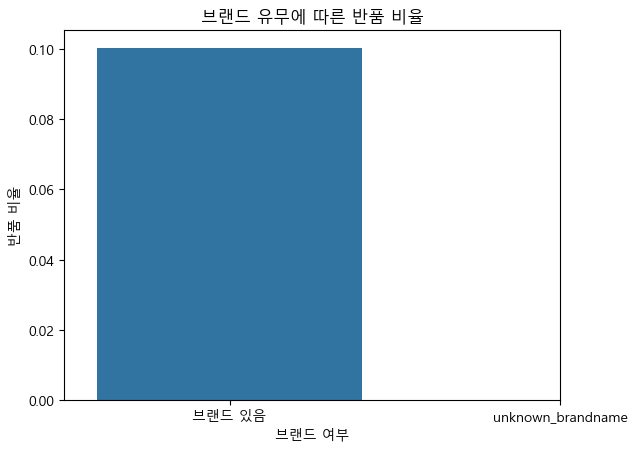

In [25]:
products = df_dict['products_EDA.csv']
order_items = df_dict['order_items_EDA.csv']
orders = df_dict['orders_EDA.csv']

# 주문 항목에 반품 여부 추가
order_items = order_items.merge(orders[['order_id', 'is_returned']], on='order_id', how='left')

# 상품 브랜드 정보 추가
order_items = order_items.merge(products[['id', 'brand']], left_on='product_id', right_on='id', how='left')

# 'unknown_brandname' 여부 컬럼 추가
order_items['is_unknown_brand'] = order_items['brand'] == 'unknown_brandname'

# 브랜드 유무에 따른 반품 비율 계산
return_by_brand_known = order_items.groupby('is_unknown_brand')['is_returned'].mean().reset_index()

# 시각화
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=return_by_brand_known, x='is_unknown_brand', y='is_returned')
plt.xticks([0, 1], ['브랜드 있음', 'unknown_brandname'])
plt.title("브랜드 유무에 따른 반품 비율")
plt.ylabel("반품 비율")
plt.xlabel("브랜드 여부")
plt.show()

- ???데이터가 많이 이쁜건지 모르겠네요..?

### 가설3. 여성이 남성보다 반품 비율이 높다.

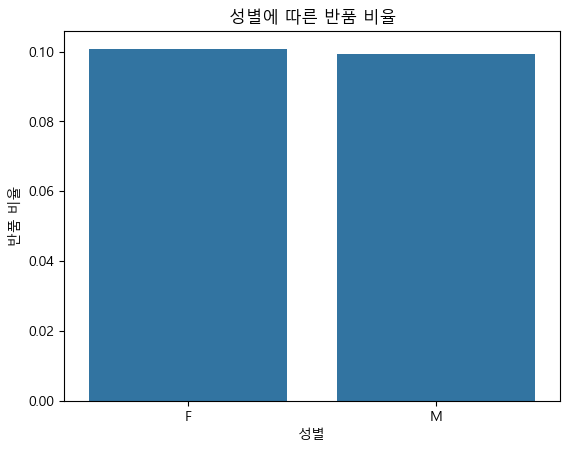

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

orders = df_dict['orders_EDA.csv']

# gender별 반품 비율 계산
return_by_gender = orders.groupby('gender')['is_returned'].mean().reset_index()

# 시각화
sns.barplot(data=return_by_gender, x='gender', y='is_returned')
plt.title("성별에 따른 반품 비율")
plt.ylabel("반품 비율")
plt.xlabel("성별")
plt.show()

- 성향을 고려했을 때 여성이 조금 더 신중한 구매를 하는 것이 맞는 것 같다

### 가설 4. 브라우저나 유입 경로에 따라 구매 행동에 차이가 있다.

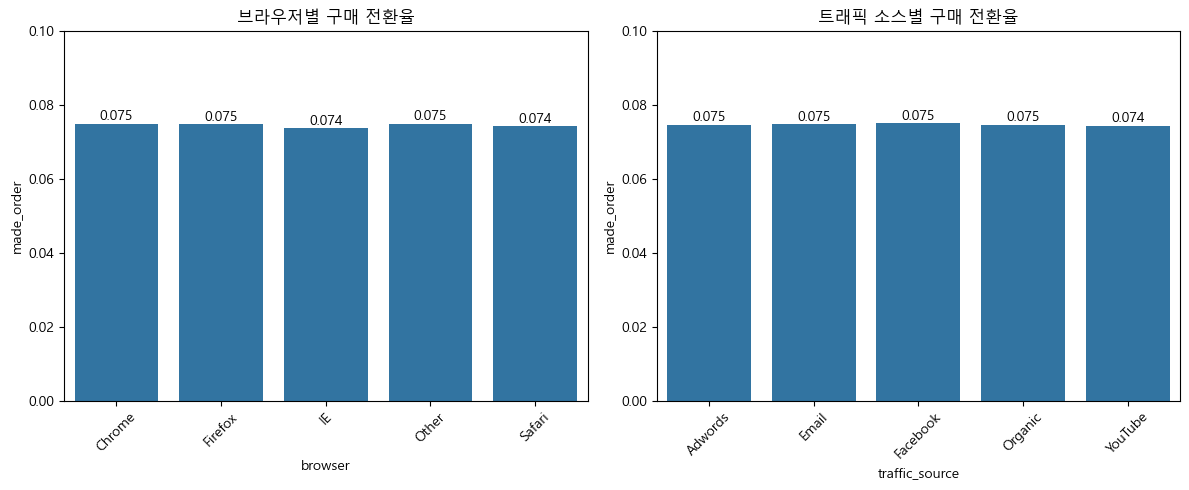

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 구매 이벤트 정의 (예: 'purchase')
events['made_order'] = events['event_type'] == 'purchase'

# 전환율 계산
browser_conv = events.groupby('browser')['made_order'].mean().reset_index()
traffic_conv = events.groupby('traffic_source')['made_order'].mean().reset_index()

# 시각화
plt.figure(figsize=(12,5))

# 브라우저별
plt.subplot(1,2,1)
sns.barplot(data=browser_conv, x='browser', y='made_order')
plt.title("브라우저별 구매 전환율")
plt.xticks(rotation=45)
plt.ylim(0, 0.1)
# 값 라벨 추가
for index, row in browser_conv.iterrows():
    plt.text(index, row['made_order'] + 0.001, f"{row['made_order']:.3f}", ha='center')

# 트래픽 소스별
plt.subplot(1,2,2)
sns.barplot(data=traffic_conv, x='traffic_source', y='made_order')
plt.title("트래픽 소스별 구매 전환율")
plt.xticks(rotation=45)
plt.ylim(0, 0.1)
for index, row in traffic_conv.iterrows():
    plt.text(index, row['made_order'] + 0.001, f"{row['made_order']:.3f}", ha='center')

plt.tight_layout()
plt.show()


- 브라우저나 유입 경로에 따라 큰 차이를 보이지는 않는다.

### 가설 5. 특정 카테고리 상품이 더 빨리 팔린다.

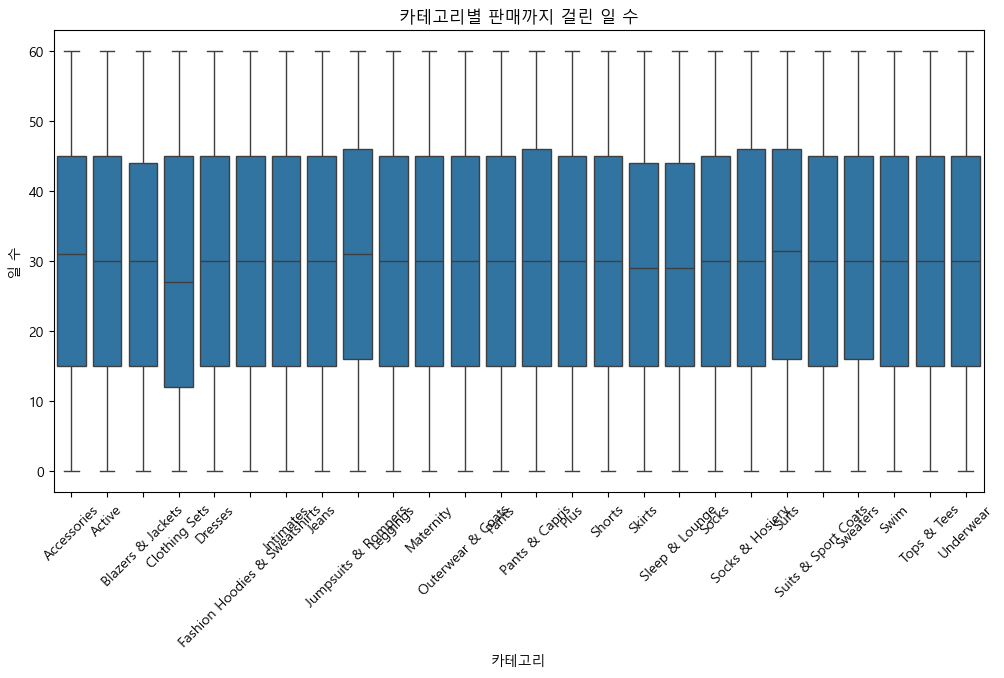

In [65]:
import pandas as pd

inventory = df_dict['inventory_items_EDA.csv']

# created_date 생성
inventory['created_date'] = pd.to_datetime({
    'year': inventory['created_year'],
    'month': inventory['created_month'],
    'day': inventory['created_day']
})

# sold_at 처리 (timezone 제거)
inventory['sold_at'] = pd.to_datetime(inventory['sold_at'], errors='coerce').dt.tz_localize(None)

# 판매까지 걸린 일 수 계산
inventory['days_to_sell'] = (inventory['sold_at'] - inventory['created_date']).dt.days

plt.figure(figsize=(12, 6))
sns.boxplot(data=inventory, x='product_category', y='days_to_sell')
plt.xticks(rotation=45)
plt.title('카테고리별 판매까지 걸린 일 수')
plt.xlabel('카테고리')
plt.ylabel('일 수')
plt.show()

- 카테고리별로 배송일은 비슷해보인다..

### 가설 6. 특정 배송센터에서 배송된 제품의 반품률이 높다.

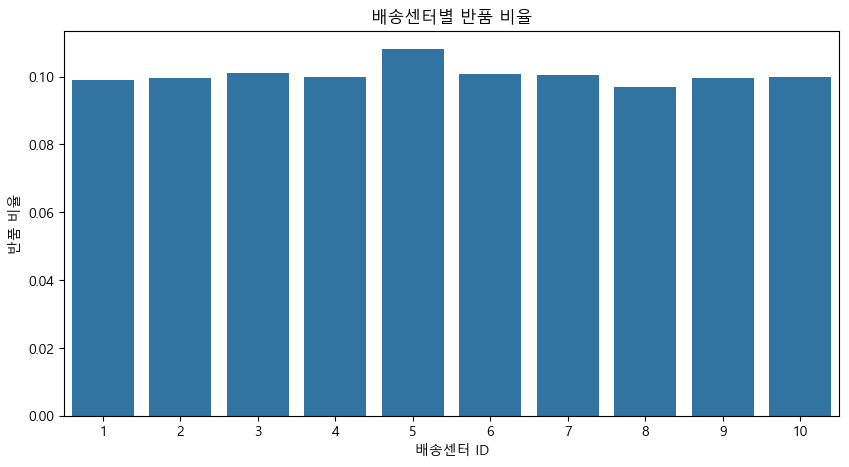

In [53]:
inventory = df_dict['inventory_items_EDA.csv']
order_items = df_dict['order_items_EDA.csv']
orders = df_dict['orders_EDA.csv']

# 반품 여부 추가
order_items = order_items.merge(orders[['order_id', 'is_returned']], on='order_id', how='left')

# 배송센터 정보 추가
order_items = order_items.merge(inventory[['id', 'product_distribution_center_id']],
                                left_on='inventory_item_id', right_on='id', how='left')

# 배송센터별 반품 비율 계산
center_return = order_items.groupby('product_distribution_center_id')['is_returned'].mean().reset_index()

# 시각화
plt.figure(figsize=(10,5))
sns.barplot(data=center_return, x='product_distribution_center_id', y='is_returned')
plt.title("배송센터별 반품 비율")
plt.xlabel("배송센터 ID")
plt.ylabel("반품 비율")
plt.show()

- 5번 배송센터의 반품 비율이 다른곳보다 확실히 높은 것을 알 수 있다.

### 가설 6-1 특정 도시의 반품률이 더 높을 것이다.

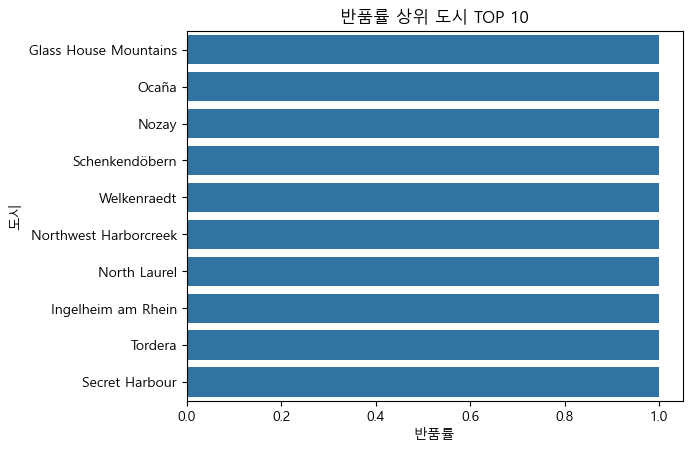

In [89]:
users = df_dict['users_EDA.csv']
orders = df_dict['orders_EDA.csv']

# 조인
merged = orders.merge(users[['id', 'city']], left_on='user_id', right_on='id')

# 도시별 반품률
city_return = merged.groupby('city')['is_returned'].mean().reset_index()

# 상위 반품률 TOP 10 도시 시각화
top_cities = city_return.sort_values(by='is_returned', ascending=False).head(10)

sns.barplot(data=top_cities, x='is_returned', y='city')
plt.title("반품률 상위 도시 TOP 10")
plt.xlabel("반품률")
plt.ylabel("도시")
plt.show()

### 가설 7. 도심 고객의 반품비율이 낮다

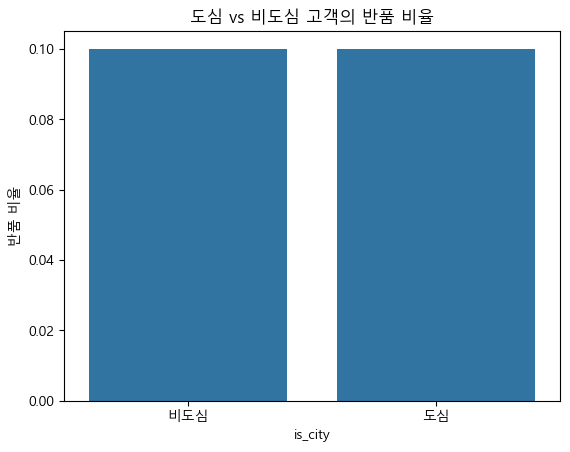

In [57]:
users = df_dict['users_EDA.csv']
orders = df_dict['orders_EDA.csv']

# 유저 위치 정보 결합
order_users = orders.merge(users[['id', 'latitude', 'longitude']], left_on='user_id', right_on='id', how='left')

# 위도 기준으로 도심/비도심 나누기 (예: 서울 기준으로 임의 설정)
order_users['is_city'] = order_users['latitude'] >= 37.5

# 도시 여부에 따른 반품 비율
return_by_area = order_users.groupby('is_city')['is_returned'].mean().reset_index()

# 시각화
sns.barplot(data=return_by_area, x='is_city', y='is_returned')
plt.xticks([0, 1], ['비도심', '도심'])
plt.title("도심 vs 비도심 고객의 반품 비율")
plt.ylabel("반품 비율")
plt.show()

- 도심이라고 반품을 더 하는 것은 아닌거같다.

### 가설 8. 특정 카테고리의 상품이 반품률이 높을까?

📊 카테고리별 평균 반품률:
             product_category  is_returned
          Jumpsuits & Rompers     0.113187
                        Suits     0.109438
                        Pants     0.105646
                       Active     0.104617
          Suits & Sport Coats     0.104536
                         Plus     0.103881
                       Shorts     0.103282
                    Maternity     0.102732
                    Intimates     0.102287
                    Underwear     0.101974
Fashion Hoodies & Sweatshirts     0.101819
            Outerwear & Coats     0.101648
                     Sweaters     0.100719
                      Dresses     0.100113
                     Leggings     0.099678
               Pants & Capris     0.099487
                         Swim     0.099139
                  Tops & Tees     0.097859
                        Jeans     0.097331
                  Accessories     0.096988
                       Skirts     0.096572
                        Socks     0.09

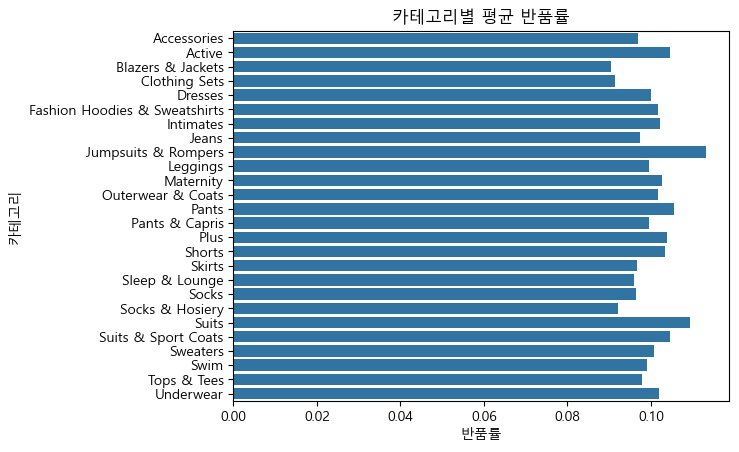

In [76]:
# inventory와 orders 연결
order_items = df_dict['order_items_EDA.csv']
inventory = df_dict['inventory_items_EDA.csv']
orders = df_dict['orders_EDA.csv']

# 조인
merged = order_items.merge(inventory[['id', 'product_category']], left_on='inventory_item_id', right_on='id') \
                    .merge(orders[['order_id', 'is_returned']], on='order_id')

# 카테고리별 반품률
category_return_rate = merged.groupby('product_category')['is_returned'].mean().reset_index()

# 수치 출력
print("📊 카테고리별 평균 반품률:")
print(category_return_rate.sort_values(by='is_returned', ascending=False).to_string(index=False))

# 시각화
sns.barplot(data=category_return_rate, x='is_returned', y='product_category')
plt.title("카테고리별 평균 반품률")
plt.xlabel("반품률")
plt.ylabel("카테고리")
plt.show()


- 점프수트가 좀 반품률이 높은 것을 알 수 있다.

### 가설 9. 주말에 주문한 제품이 리드타임이 더 길 것이다.

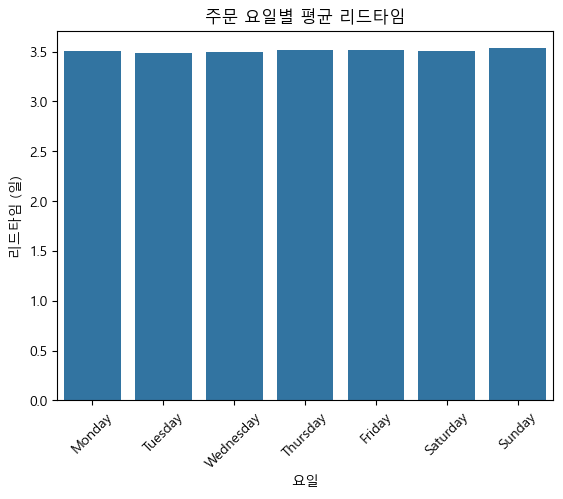

In [79]:
orders = df_dict['orders_EDA.csv']

# 요일 이름 추출
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['weekday'] = orders['created_at'].dt.day_name()

# 요일별 평균 리드타임
weekday_lead = orders.groupby('weekday')['lead_time'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()

# 시각화
sns.barplot(data=weekday_lead, x='weekday', y='lead_time')
plt.title("주문 요일별 평균 리드타임")
plt.ylabel("리드타임 (일)")
plt.xlabel("요일")
plt.xticks(rotation=45)
plt.show()

- 요일에 따른 리드타임의 큰 차이는 없어보인다.

### 가설 10. 연령대에 따라 반품률이 다르다.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14528\2605173924.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_return = merged.groupby('age_group')['is_returned'].mean().reset_index()


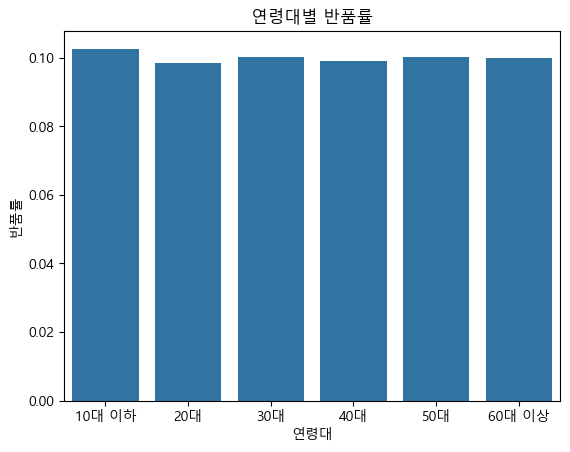

In [91]:
users = df_dict['users_EDA.csv']
orders = df_dict['orders_EDA.csv']

# 연령대 구간화
users['age_group'] = pd.cut(users['age'], bins=[0, 19, 29, 39, 49, 59, 100],
                            labels=['10대 이하', '20대', '30대', '40대', '50대', '60대 이상'])

# 조인 및 반품률 계산
merged = orders.merge(users[['id', 'age_group']], left_on='user_id', right_on='id')
age_return = merged.groupby('age_group')['is_returned'].mean().reset_index()

# 시각화
sns.barplot(data=age_return, x='age_group', y='is_returned')
plt.title("연령대별 반품률")
plt.ylabel("반품률")
plt.xlabel("연령대")
plt.show()

- 10대 이하가 조금 높은 경향을 보이나 유의미하진 않아보인다.

### 가설 11. 할인율이 높을수록 반품 확률이 증가한다.

  discount_group  is_returned
0          0-10%     0.100274
1         10-20%          NaN
2         20-30%          NaN
3           30%+          NaN


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14528\2019563932.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_return = merged.groupby('discount_group')['is_returned'].mean().reset_index()


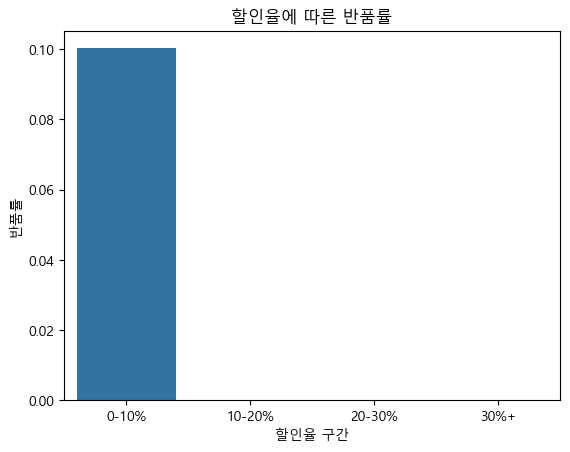

In [101]:
order_items = df_dict['order_items_EDA.csv']
inventory = df_dict['inventory_items_EDA.csv']
orders = df_dict['orders_EDA.csv']

# order_items에 inventory의 정가(retail_price) 추가
merged = order_items.merge(inventory[['id', 'product_retail_price']], left_on='inventory_item_id', right_on='id', how='left')

# 할인율 계산
merged['discount_rate'] = (merged['product_retail_price'] - merged['sale_price']) / merged['product_retail_price']

# 주문 정보 병합
merged = merged.merge(orders[['order_id', 'is_returned']], on='order_id', how='left')

# 할인율 구간화
merged['discount_group'] = pd.cut(merged['discount_rate'], bins=[-0.01, 0.1, 0.2, 0.3, 1],
                                   labels=['0-10%', '10-20%', '20-30%', '30%+'])

# 구간별 반품률 계산
discount_return = merged.groupby('discount_group')['is_returned'].mean().reset_index()
print(discount_return)

# 시각화
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=discount_return, x='discount_group', y='is_returned')
plt.title("할인율에 따른 반품률")
plt.xlabel("할인율 구간")
plt.ylabel("반품률")
plt.show()

- 할인율이 높아지자 반품 건이 없어졌다.
- 가격 할인에 따른 만족감이 반품을 없애는 것 같다. 

### 가설 12. 배송 소요 시간이 길수록 주문당 매출액은 감소할 것이다.

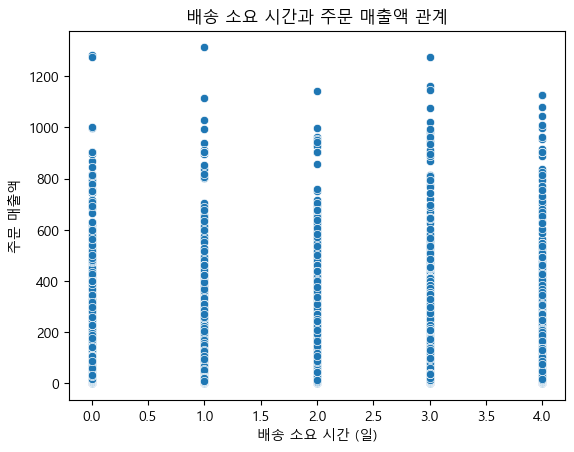

In [107]:
orders = df_dict['orders_EDA.csv']
order_items = df_dict['order_items_EDA.csv']

# 주문별 매출액 계산
order_sales = order_items.groupby('order_id')['sale_price'].sum().reset_index()

# orders와 병합
merged = orders.merge(order_sales, on='order_id')

# 배송기간(shipping_days)과 매출액(sale_price) 관계 시각화
sns.scatterplot(data=merged, x='shipping_days', y='sale_price')
plt.title("배송 소요 시간과 주문 매출액 관계")
plt.xlabel("배송 소요 시간 (일)")
plt.ylabel("주문 매출액")
plt.show()



- 큰 차이는 없으나 배송 소요 시간이 길수록 높은 가격의 물건들이 조금 더 판매되는 것을 확인할 수 있다.


### 가설 13. 상품 배송 센터(distribution_center_id)에 따라 매출 성과가 다르다

   product_distribution_center_id  sales_amount  is_returned
0                               1  1.379884e+06     0.099081
1                               2  1.299937e+06     0.099675
2                               3  1.542386e+06     0.101091
3                               4  9.220595e+05     0.099787
4                               5  7.987787e+05     0.108116
5                               6  9.099537e+05     0.100762
6                               7  1.048013e+06     0.100568
7                               8  1.232766e+06     0.096829
8                               9  6.510805e+05     0.099412
9                              10  7.745110e+05     0.099837


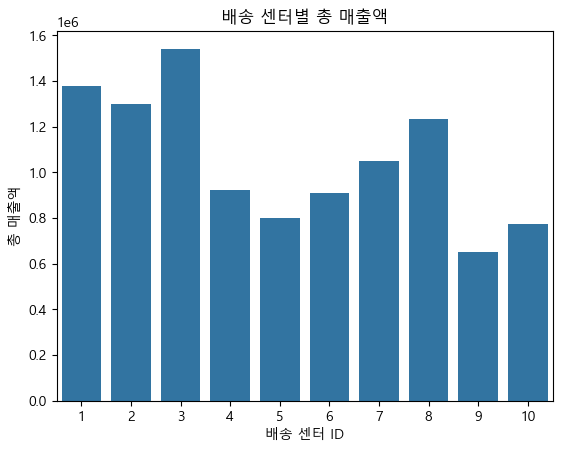

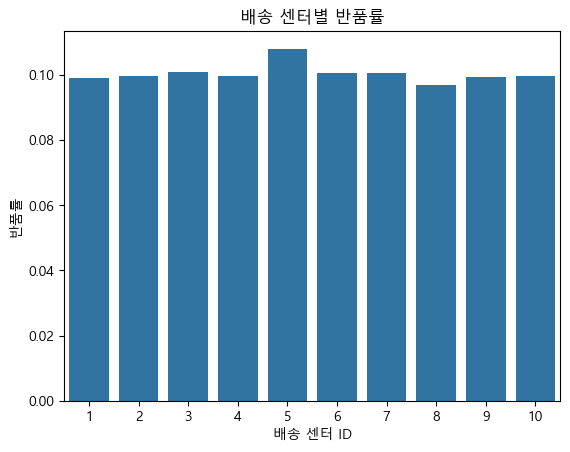

In [110]:
order_items = df_dict['order_items_EDA.csv']
inventory = df_dict['inventory_items_EDA.csv']
orders = df_dict['orders_EDA.csv']

# order_items + inventory로 distribution_center_id 가져오기
merged = order_items.merge(inventory[['id', 'product_distribution_center_id']], left_on='inventory_item_id', right_on='id')

# 주문별 매출액 계산
merged['sales_amount'] = merged['sale_price']

# distribution_center_id별 총 매출액 및 반품률 계산
center_sales = merged.groupby('product_distribution_center_id')['sales_amount'].sum().reset_index()
center_returns = merged.merge(orders[['order_id', 'is_returned']], on='order_id').groupby('product_distribution_center_id')['is_returned'].mean().reset_index()

# 합치기
center_stats = center_sales.merge(center_returns, on='product_distribution_center_id')

print(center_stats)

# 시각화 - 총 매출액
sns.barplot(data=center_stats, x='product_distribution_center_id', y='sales_amount')
plt.title("배송 센터별 총 매출액")
plt.xlabel("배송 센터 ID")
plt.ylabel("총 매출액")
plt.show()

# 시각화 - 반품률
sns.barplot(data=center_stats, x='product_distribution_center_id', y='is_returned')
plt.title("배송 센터별 반품률")
plt.xlabel("배송 센터 ID")
plt.ylabel("반품률")
plt.show()